## Lab6-Assignment: Topic Classification

Use the same training, development, and test partitions of the the 20 newsgroups text dataset as in Lab6.4-Topic-classification-BERT.ipynb 

* Fine-tune and examine the performance of another transformer-based pretrained language models, e.g., RoBERTa, XLNet

* Compare the performance of this model to the results achieved in Lab6.4-Topic-classification-BERT.ipynb and to a conventional machine learning approach (e.g., SVM, Naive Bayes) using bag-of-words or other engineered features of your choice. 
Describe the differences in performance in terms of Precision, Recall, and F1-score evaluation metrics.

## 1. Install & Import Libraries

In [2]:
!pip install transformers==4.57.6
!pip install simpletransformers==0.70.5

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 100.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 44.5 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.11.0
    Uninstalling huggingface_hub-1.11.0:
      Successfully uninstalled huggingface_hub-1.11.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 330.8/330.8 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 134.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from simpletransformers.classification import ClassificationModel, ClassificationArgs
import matplotlib.pyplot as plt

print('All libraries imported successfully.')

All libraries imported successfully.


## 2. Load & Split the Data

Using the same 4 categories, train/dev/test split, and random seeds as Lab 6.4.

In [4]:
categories = ['alt.atheism', 'comp.graphics', 'sci.med', 'sci.space']

newsgroups_train = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'),
                                      categories=categories, random_state=42)
newsgroups_test  = fetch_20newsgroups(subset='test',  remove=('headers', 'footers', 'quotes'),
                                      categories=categories, random_state=42)

train_full = pd.DataFrame({'text': newsgroups_train.data, 'labels': newsgroups_train.target})
test_df    = pd.DataFrame({'text': newsgroups_test.data,  'labels': newsgroups_test.target})

train_df, dev_df = train_test_split(train_full, test_size=0.1, random_state=0,
                                    stratify=train_full[['labels']])

print(f'Train: {len(train_df)} | Dev: {len(dev_df)} | Test: {len(test_df)}')
print(f'Label mapping: {dict(enumerate(newsgroups_train.target_names))}')

Train: 2025 | Dev: 226 | Test: 1498
Label mapping: {0: 'alt.atheism', 1: 'comp.graphics', 2: 'sci.med', 3: 'sci.space'}


## 3. Fine-tune RoBERTa

**RoBERTa** (Robustly Optimized BERT Pretraining Approach) is a BERT variant trained with more data, dynamic masking, no next-sentence prediction, and larger mini-batches — changes that generally yield stronger downstream performance.

The setup below is identical to Lab 6.4's BERT section. The only differences are:
- `model_type`: `'bert'` → `'roberta'`
- `model_name`: `'bert-base-cased'` → `'roberta-base'`

In [ ]:
model_args = ClassificationArgs()

model_args.overwrite_output_dir = True
model_args.evaluate_during_training = True

model_args.num_train_epochs = 10
model_args.train_batch_size = 32
model_args.learning_rate = 4e-6
model_args.max_seq_length = 256

model_args.use_early_stopping = True
model_args.early_stopping_delta = 0.01
model_args.early_stopping_metric = 'eval_loss'
model_args.early_stopping_metric_minimize = True
model_args.early_stopping_patience = 2
model_args.evaluate_during_training_steps = 32

model_args.output_dir = 'roberta_output/'
model_args.best_model_dir = 'roberta_output/best_model/'

In [6]:
steps_per_epoch = int(np.ceil(len(train_df) / float(model_args.train_batch_size)))
print('Each epoch will have {:,} steps.'.format(steps_per_epoch))

Each epoch will have 64 steps.


In [ ]:
# Load RoBERTa
model = ClassificationModel(
    'roberta',       
    'roberta-base',  
    num_labels=4,
    args=model_args,
    use_cuda=True
)
print('RoBERTa loaded.')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

RoBERTa loaded.


In [ ]:
_, history = model.train_model(train_df, eval_df=dev_df)
print('Fine-tuning complete.')

/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:544: UserWarning: The 'eval_df' parameter has been deprecated and will be removed in a future version. Please use 'eval_data' instead.
  warnings.warn(


  0%|          | 0/4 [00:00<?, ?it/s]

Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:924: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()


Running Epoch 1 of 10:   0%|          | 0/64 [00:00<?, ?it/s]

...

/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:1570: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


Running Epoch 7 of 10:   0%|          | 0/64 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:950: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


0it [00:00, ?it/s]

/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:1570: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


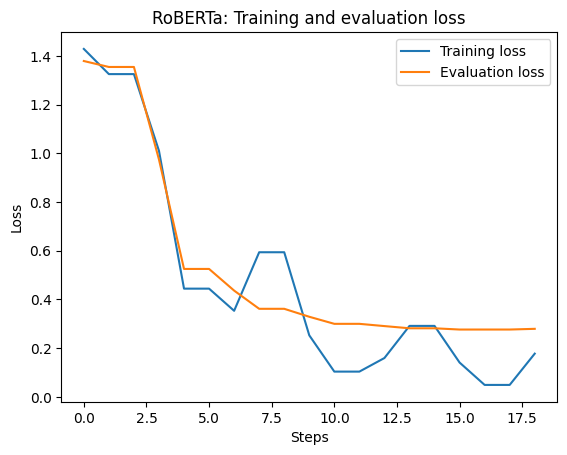

In [ ]:
# Training and evaluation loss plot
plt.plot(history['train_loss'], label='Training loss')
plt.plot(history['eval_loss'],  label='Evaluation loss')
plt.title('RoBERTa: Training and evaluation loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()
plt.show()

## 4. Evaluate RoBERTa

In [13]:
# Evaluate on dev set
result, _, _ = model.eval_model(dev_df)
print('Dev set results (mcc = Matthews Correlation Coefficient):')
print(result)

0it [00:00, ?it/s]

Running Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:1570: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


Dev set results (mcc = Matthews Correlation Coefficient):
{'mcc': np.float64(0.8406439919553071), 'eval_loss': 0.27949026723702747}


In [ ]:
# Predict on test set and classification report
predicted, _ = model.predict(test_df['text'].to_list())
test_df['predicted'] = predicted

print(classification_report(test_df['labels'], predicted,
                             target_names=newsgroups_train.target_names))

  0%|          | 0/2 [00:00<?, ?it/s]

Predicting:   0%|          | 0/15 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:2260: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


               precision    recall  f1-score   support

  alt.atheism       0.84      0.81      0.82       319
comp.graphics       0.83      0.93      0.88       389
      sci.med       0.90      0.89      0.89       396
    sci.space       0.88      0.81      0.84       394

     accuracy                           0.86      1498
    macro avg       0.86      0.86      0.86      1498
 weighted avg       0.86      0.86      0.86      1498



## Results Comparison

#### Classification Report: BERT
| Class | Precision | Recall | F1 |
|---|---|---|---|
| alt.atheism | 0.85 | 0.78 | 0.81 |
| comp.graphics | 0.82 | 0.93 | 0.87 |
| sci.med | 0.93 | 0.89 | 0.91 |
| sci.space | 0.85 | 0.82 | 0.84 |
| **accuracy** | | | **0.86** |
| **macro avg** | **0.86** | **0.86** | **0.86** |
| **weighted avg** | **0.86** | **0.86** | **0.86** |

#### Classification Report: RoBERTa
| Class | Precision | Recall | F1 |
|---|---|---|---|
| alt.atheism | 0.84 | 0.81 | 0.82 |
| comp.graphics | 0.83 | 0.93 | 0.88 |
| sci.med | 0.90 | 0.89 | 0.89 |
| sci.space | 0.88 | 0.81 | 0.84 |
| **accuracy** | | | **0.86** |
| **macro avg** | **0.86** | **0.86** | **0.86** |
| **weighted avg** | **0.86** | **0.86** | **0.86** |

#### Dev Set Metrics

| Model | MCC | Eval Loss |
|---|---|---|
| BERT | 0.836 | 0.376 |
| RoBERTa | 0.841 | 0.279 |

### Overall Performance 

Both models achieve a **macro F1 of 0.86** and **86% overall accuracy** on the test set, which at first glance suggests no meaningful difference between them. However, looking at the dev set metrics tells a more nuanced story, RoBERTa achieves a slightly higher MCC (0.841 vs 0.836) and a notably **lower eval loss** (0.279 vs 0.376). This means RoBERTa's probability estimates are better calibrated even when the final hard predictions come out the same.

### Per-Class Differences

The differences are small but meaningful when examined at the category level.

- **alt.atheism** — RoBERTa improves recall from 0.78 to 0.81, meaning it misses fewer atheism posts. This is the hardest category as it often overlaps thematically with other categories in terms of argumentative language. RoBERTa's richer pretraining helps it distinguish these subtle differences.

- **comp.graphics** — Both models perform nearly identically here (F1 0.87 vs 0.88). This is likely the easiest category because graphics terminology is highly domain-specific and distinctive, making it straightforward for both models.

- **sci.med** — BERT actually edges out RoBERTa here (F1 0.91 vs 0.89). BERT's precision is higher (0.93 vs 0.90), suggesting it is more conservative and accurate when predicting medical posts. This could be because medical vocabulary is highly specific and BERT's cased tokenization preserves the capitalisation of medical terms better than RoBERTa's tokenizer.

- **sci.space** — Both achieve the same F1 (0.84), though RoBERTa has higher precision (0.88 vs 0.85) while recall is identical. RoBERTa makes fewer false positives for this category.

<div style="display:flex; gap:10px;">
    <div style="text-align:center;">
        <img src="graphs/BERT.png" width="400">
        <p><b>Figure 1: BERT Training and Evaluation Loss</b></p>
    </div>
    <div style="text-align:center;">
        <img src="graphs/RoBERTa.png" width="400">
        <p><b>Figure 2: RoBERTa Training and Evaluation Loss</b></p>
    </div>
</div>

### Loss Curves

Both models follow a similar training pattern, a rapid loss drop in the first few steps, followed by fluctuating training loss while evaluation loss gradually stabilises. However, RoBERTa's curve is **smoother and converges to a lower final eval loss** (~0.28 vs ~0.38 for BERT). This indicates RoBERTa generalises better to unseen data, even though this advantage does not translate into higher test accuracy on this particular dataset. This is a known phenomenon — on small, well-separated datasets, both models can saturate near the same performance ceiling regardless of architectural differences.

### Why Are the Results So Similar?

- The **4-category subset** is a relatively easy and small classification task — both models have more than enough capacity to learn it well, leaving little room for one to outperform the other.
- Both models used **identical hyperparameters** (same learning rate, batch size, epochs, early stopping), meaning any architectural advantage RoBERTa has was not fully explored. A tuned learning rate or more training steps might reveal a clearer gap.
- RoBERTa's pretraining improvements — dynamic masking, more data, no next-sentence prediction — matter most on **harder tasks** with more subtle distinctions, larger label spaces, or noisier text.

### Conclusion

RoBERTa is a marginally stronger model on this task, it achieves a slightly higher MCC and substantially lower eval loss on the dev set, but the practical difference on this specific dataset is negligible. Both models achieve the same macro F1 of 0.86. For a more complex topic classification task with more categories, more ambiguous text, or a larger dataset, RoBERTa's stronger pretraining would likely produce a clearer and more consistent advantage over BERT.